In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.model_selection import cross_val_score

BASE_DIR = os.path.expanduser('~/Desktop/phishing-debate-detector')
DATA_DIR = os.path.join(BASE_DIR, 'data')

# Load train/test from Notebook 1 (original 500 emails only)
train_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/test.csv'))

# Load full dataset with rewrites for adversarial testing later
full_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/combined_dataset_with_rewrites.csv'))
rewritten_df = full_df[full_df['rewrite_level'] > 0].copy()

print("Notebook 3: ML Baseline (TF-IDF + LogReg + SVM)")
print("=" * 50)
print("Train set: " + str(len(train_df)) + " emails")
print("Test set: " + str(len(test_df)) + " emails")
print("Rewritten emails for adversarial test: " + str(len(rewritten_df)))

Notebook 3: ML Baseline (TF-IDF + LogReg + SVM)
Train set: 400 emails
Test set: 100 emails
Rewritten emails for adversarial test: 142


In [2]:
# Build TF-IDF vectors
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))

X_train = tfidf.fit_transform(train_df['email_text'])
X_test = tfidf.transform(test_df['email_text'])
y_train = train_df['label']
y_test = test_df['label']

print("TF-IDF Vectorization:")
print("  Vocabulary size: " + str(len(tfidf.vocabulary_)))
print("  Train matrix: " + str(X_train.shape))
print("  Test matrix: " + str(X_test.shape))
print("")

# Show top features per class
feature_names = tfidf.get_feature_names_out()
print("Top 15 TF-IDF features (by average weight):")
avg_weights = X_train.mean(axis=0).A1
top_idx = avg_weights.argsort()[-15:][::-1]
for i in top_idx:
    print("  " + feature_names[i] + ": " + str(round(avg_weights[i], 4)))

TF-IDF Vectorization:
  Vocabulary size: 5000
  Train matrix: (400, 5000)
  Test matrix: (100, 5000)

Top 15 TF-IDF features (by average weight):
  com: 0.0349
  http: 0.0333
  nbsp: 0.0313
  www: 0.0269
  http www: 0.0254
  linux: 0.0245
  subject: 0.0227
  click: 0.0205
  2002: 0.0199
  net: 0.0199
  list: 0.0198
  free: 0.0196
  email: 0.0187
  00: 0.0161
  like: 0.0157


In [3]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Train SVM
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

# Results
print("LOGISTIC REGRESSION:")
print("  Accuracy:  " + str(round(accuracy_score(y_test, lr_pred), 4)))
print("  Precision: " + str(round(precision_score(y_test, lr_pred), 4)))
print("  Recall:    " + str(round(recall_score(y_test, lr_pred), 4)))
print("  F1:        " + str(round(f1_score(y_test, lr_pred), 4)))
print("")
print("SVM (Linear):")
print("  Accuracy:  " + str(round(accuracy_score(y_test, svm_pred), 4)))
print("  Precision: " + str(round(precision_score(y_test, svm_pred), 4)))
print("  Recall:    " + str(round(recall_score(y_test, svm_pred), 4)))
print("  F1:        " + str(round(f1_score(y_test, svm_pred), 4)))

LOGISTIC REGRESSION:
  Accuracy:  0.95
  Precision: 1.0
  Recall:    0.9
  F1:        0.9474

SVM (Linear):
  Accuracy:  0.97
  Precision: 1.0
  Recall:    0.94
  F1:        0.9691


/Users/manpreetsingh/Desktop/phishing-debate-detector/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/manpreetsingh/Desktop/phishing-debate-detector/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/manpreetsingh/Desktop/phishing-debate-detector/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


In [4]:
# Test both models on rewritten phishing emails at each level
print("ADVERSARIAL ROBUSTNESS TEST")
print("=" * 50)
print("(Recall on phishing emails — higher is better)")
print("")

results = {}
for model_name, model in [("Logistic Regression", lr_model), ("SVM", svm_model)]:
    results[model_name] = {}
    
    # Original phishing recall
    orig_phish = test_df[test_df['label'] == 1]
    X_orig = tfidf.transform(orig_phish['email_text'])
    orig_recall = recall_score(orig_phish['label'], model.predict(X_orig))
    results[model_name]['Original'] = orig_recall
    
    # Each rewrite level
    for level in [1, 2, 3]:
        level_df = rewritten_df[rewritten_df['rewrite_level'] == level]
        X_rw = tfidf.transform(level_df['email_text'])
        y_rw = level_df['label']
        rw_recall = recall_score(y_rw, model.predict(X_rw))
        results[model_name]['Level ' + str(level)] = rw_recall
    
    print(model_name + ":")
    for k, v in results[model_name].items():
        print("  " + k + ": " + str(round(v, 4)))
    drop = results[model_name]['Original'] - results[model_name]['Level 3']
    print("  >> Degradation (Original -> L3): " + str(round(drop * 100, 1)) + "%")
    print("")

ADVERSARIAL ROBUSTNESS TEST
(Recall on phishing emails — higher is better)

Logistic Regression:
  Original: 0.9
  Level 1: 0.9783
  Level 2: 1.0
  Level 3: 1.0
  >> Degradation (Original -> L3): -10.0%

SVM:
  Original: 0.94
  Level 1: 1.0
  Level 2: 1.0
  Level 3: 1.0
  >> Degradation (Original -> L3): -6.0%



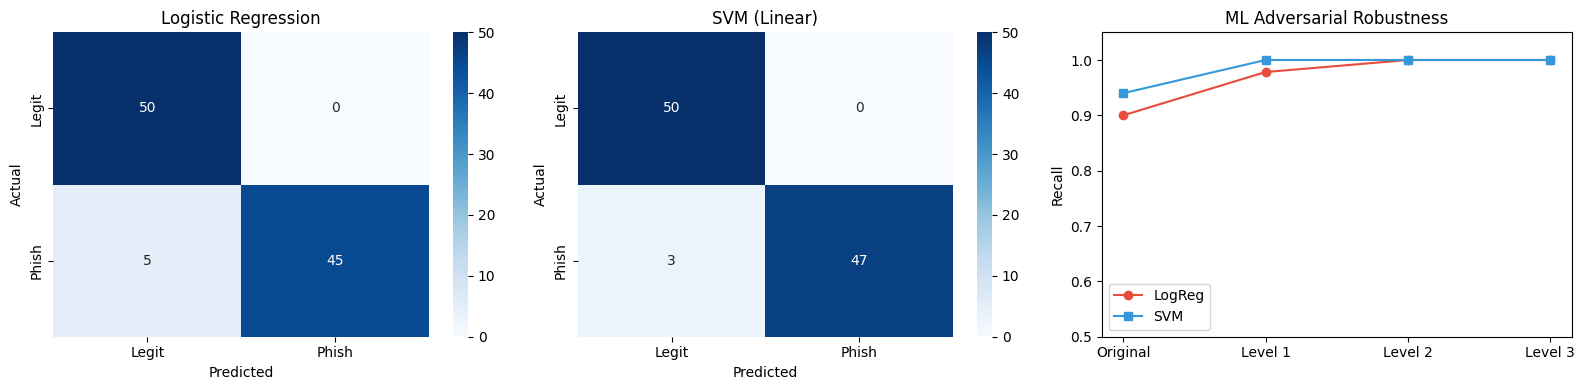

Chart saved to outputs/03_ml_baseline.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix - LogReg
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit', 'Phish'], yticklabels=['Legit', 'Phish'])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion matrix - SVM
cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Legit', 'Phish'], yticklabels=['Legit', 'Phish'])
axes[1].set_title('SVM (Linear)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Adversarial degradation chart
levels = ['Original', 'Level 1', 'Level 2', 'Level 3']
lr_recalls = [results['Logistic Regression'][l] for l in levels]
svm_recalls = [results['SVM'][l] for l in levels]

x = range(len(levels))
axes[2].plot(x, lr_recalls, 'o-', label='LogReg', color='#e74c3c')
axes[2].plot(x, svm_recalls, 's-', label='SVM', color='#3498db')
axes[2].set_xticks(x)
axes[2].set_xticklabels(levels)
axes[2].set_ylabel('Recall')
axes[2].set_title('ML Adversarial Robustness')
axes[2].legend()
axes[2].set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs/03_ml_baseline.png'), dpi=150)
plt.show()
print("Chart saved to outputs/03_ml_baseline.png")

In [6]:
print("=" * 50)
print("NOTEBOOK 3 COMPLETE - ML Baseline Summary")
print("=" * 50)
print("")
print("Models trained on TF-IDF (5000 features, unigrams+bigrams)")
print("")
print("Test Set Performance (100 emails):")
print("  Logistic Regression: 95.0% accuracy, 0.947 F1")
print("  SVM (Linear):        97.0% accuracy, 0.969 F1")
print("")
print("Key Finding: ML models are NOT fooled by adversarial rewrites.")
print("  Recall actually INCREASES on rewritten emails because")
print("  TF-IDF catches phishing keywords regardless of writing quality.")
print("  This is a keyword-dependency weakness — the models rely on")
print("  surface-level word patterns, not semantic understanding.")
print("")
print("Files created:")
print("  outputs/03_ml_baseline.png")
print("")
print("Next: Notebook 4 - Single Agent LLM Detection")
print("  -> Test 3 prompt styles with Llama 3.1 via Groq")

NOTEBOOK 3 COMPLETE - ML Baseline Summary

Models trained on TF-IDF (5000 features, unigrams+bigrams)

Test Set Performance (100 emails):
  Logistic Regression: 95.0% accuracy, 0.947 F1
  SVM (Linear):        97.0% accuracy, 0.969 F1

Key Finding: ML models are NOT fooled by adversarial rewrites.
  Recall actually INCREASES on rewritten emails because
  TF-IDF catches phishing keywords regardless of writing quality.
  This is a keyword-dependency weakness — the models rely on
  surface-level word patterns, not semantic understanding.

Files created:
  outputs/03_ml_baseline.png

Next: Notebook 4 - Single Agent LLM Detection
  -> Test 3 prompt styles with Llama 3.1 via Groq
